https://pymoo.org/algorithms/moo/nsga2.html

In [12]:
import pymoo.gradient.toolbox as anp
import numpy as np
import pandas as pd
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.visualization.scatter import Scatter
from pymoo.optimize import minimize

import matplotlib.pyplot as plt

import plotly.express as px

import tensorflow as tf
from tensorflow import keras
from keras.models import load_model
from pickle import load

In [13]:
class func(Problem):
    def __init__(self):
        super().__init__(n_var=2, n_obj=2, n_ieq_constr=2, vtype=float)
        self.xl = np.array([0.1, 0])
        self.xu = np.array([1.0, 5])

    def _evaluate(self, x, out, *args, **kwargs):
        f1 = x[:, 0] # objective
        f2 = (1 + x[:, 1]) / x[:, 0]

        g1 = 9 * x[:, 0] + x[:, 1] - 6 # const, >=0 
        g2 = 9 * x[:, 0] - x[:, 1] - 1 # const, >=0

        out["F"] = anp.column_stack([f1, f2])

        out["G"] = anp.column_stack([g1, g2])
        out["G"] = - out["G"]

In [14]:
problem = func()

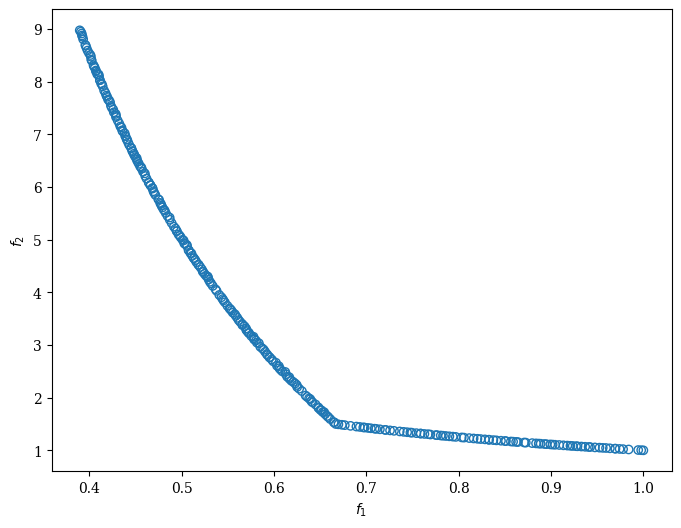

In [15]:
algorithm = NSGA2(pop_size=300)

res = minimize(problem,
               algorithm,
               ('n_gen', 200),
               seed=1,
               verbose=False)

plot = Scatter()
# plot.add(problem.pareto_front())
plot.add(res.F, facecolor="none")
plot.show()

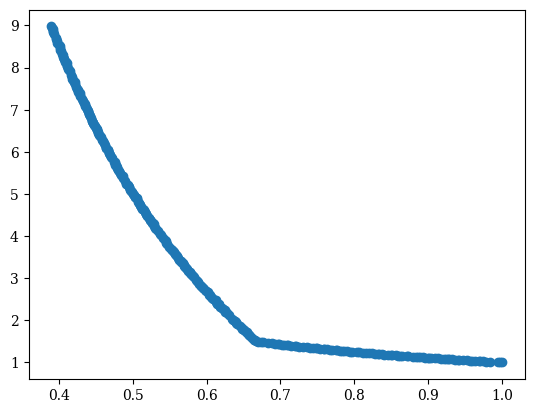

In [16]:
plt.scatter(res.F[:,0], res.F[:,1])
plt.show()

https://wikidocs.net/185748

In [17]:
fig = px.scatter(x=res.F[:, 0], y=res.F[:, 1], width=800, height=600)
fig.show()